In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm

In [2]:
df = pd.read_csv("insurance.csv") 
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
### Markdown
Age, BMI, smoking status, and region are among the lifestyle and demographic factors included in the dataset. 
The.info() output verifies that the data types are suitable for analysis and that there are no missing values. 
The distribution and range of numerical variables are revealed by the.describe() summary.

In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
### Markdown
The dataset had no missing values, suggesting excellent data quality. 
This enables immediate analysis and does away with the requirement for imputation

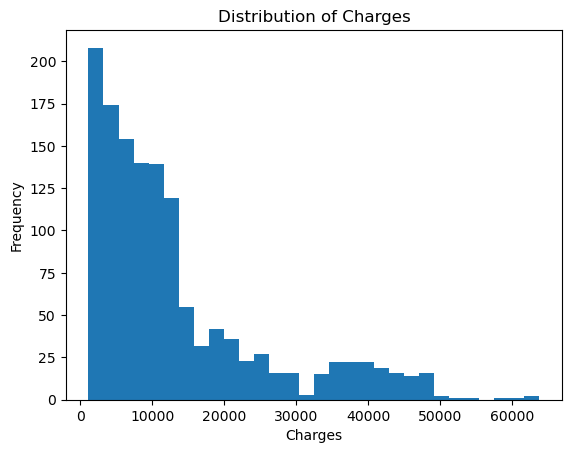

In [5]:
plt.hist(df['charges'], bins=30)
plt.title("Distribution of Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

In [ ]:
### Markdown
A small percentage of people have extremely high medical costs, while the majority of 
people have lower costs due to a positively skewed distribution. This skewness implies that changes of the data might be beneficial.

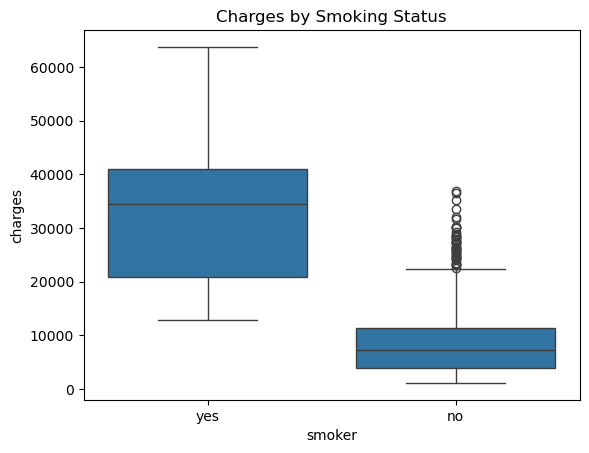

In [6]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoking Status")
plt.show()

In [ ]:
### Markdown
The boxplot clearly shows that medical expenses for smokers are far higher than those for non-smokers.
This suggests that healthcare expenses are strongly predicted by smoking status.

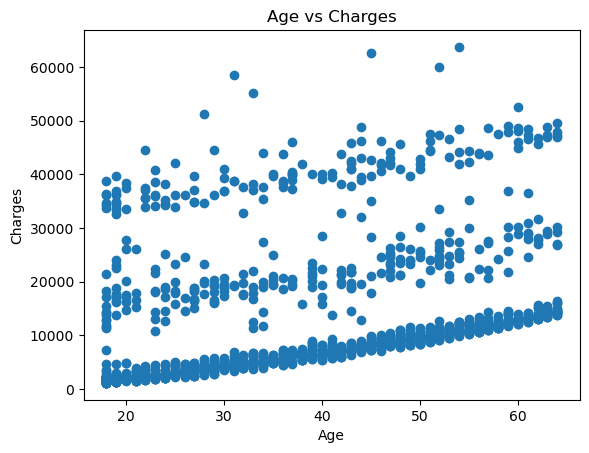

In [7]:
plt.scatter(df['age'], df['charges'])
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.show()

In [ ]:
### Markdown
Age and charges are positively correlated, indicating that healthcare expenses rise with age.

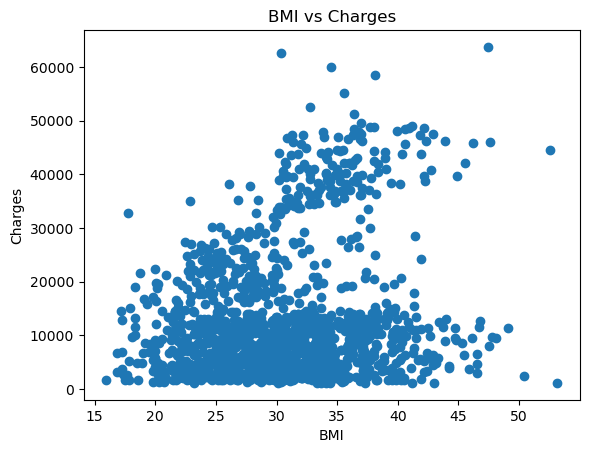

In [8]:
plt.scatter(df['bmi'], df['charges'])
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges")
plt.show()

In [ ]:
BMI and charges have a slightly positive correlation. 
Although there is significant variation, people with higher BMIs often have greater medical costs.

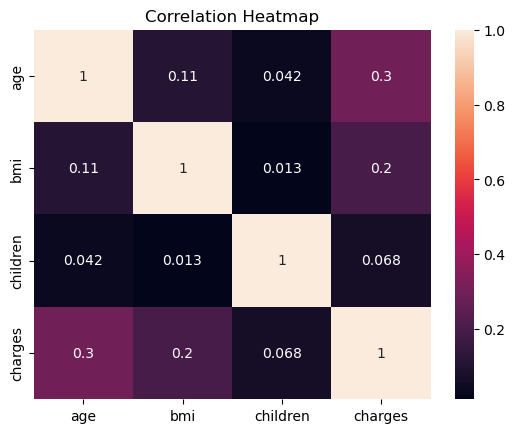

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
Age, BMI, and smoking status had the biggest associations with medical expenses, according to the heatmap. 
    These factors are probably the model's most significant predictors.

In [11]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
df.dtypes

age                   int64
bmi                 float64
children              int64
charges             float64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

In [ ]:
### Markdown
One-hot encoding was used to transform categorical variables like sex, smoker, and region into
numerical format so they could be used in regression research.

In [14]:
df = pd.get_dummies(df, drop_first=True)

# Convert ALL columns to numeric
df = df.apply(pd.to_numeric)

In [16]:
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric)

X = df.drop('charges', axis=1)
y = df['charges']

X = X.astype(float)
y = y.astype(float)

import statsmodels.api as sm
X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        07:38:04   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

In [ ]:
### Markdown
Each variable's statistical significance was assessed using Ordinary Least Squares (OLS) regression.
Significant variables were kept for modelling if their p-values were less than 0.05.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
### Markdown
To ensure that the model is tested on unknown data,
the dataset was divided into training and testing sets (80/20).

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
### Markdown
The training data was used to train a Multiple Linear Regression model. 
By estimating coefficients, the model identifies the link between the independent variables and the target variable.

In [19]:
y_pred = model.predict(X_test)

In [ ]:
### Markdown
The test dataset's medical expenses were predicted using the trained model.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4152.142264696874
RMSE: 6071.188810599624
R² Score: 0.7200269818164975


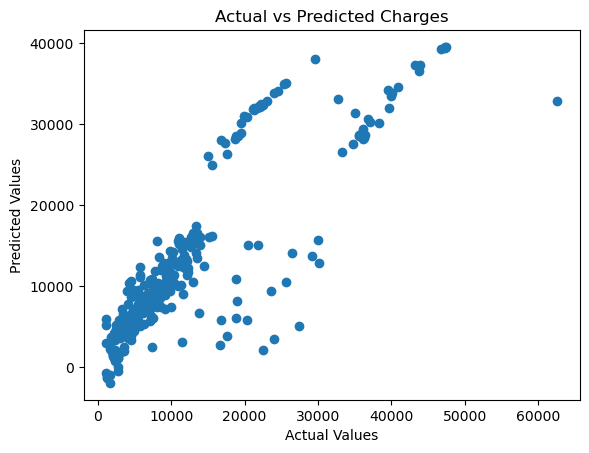

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Charges")
plt.show()

In [1]:
### Markdown
The model's ability to predict medical expenses is average. 
While MAE and RMSE display the size of prediction errors, the R² value shows how much of the variable in charges is explained by the predictors. 

In [24]:
df['log_charges'] = np.log(df['charges'])

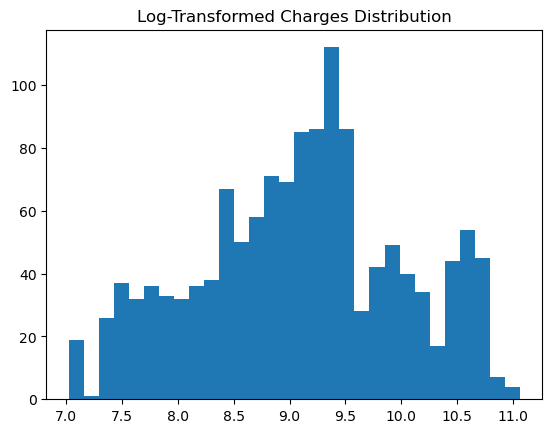

In [25]:
plt.hist(df['log_charges'], bins=30)
plt.title("Log-Transformed Charges Distribution")
plt.show()

In [ ]:
### Markdown
By normalizing the distribution and reducing skewness, the log transformation improves its suitability for linear regression.

In [26]:
y_log = df['log_charges']

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [27]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Improved MAE:", mae)
print("Improved RMSE:", rmse)
print("Improved R²:", r2)

Improved MAE: 0.2651726241289403
Improved RMSE: 0.4151966043034281
Improved R²: 0.7827657958089478


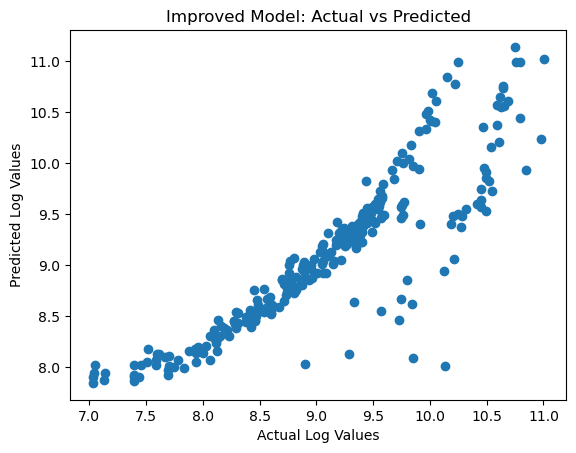

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Log Values")
plt.ylabel("Predicted Log Values")
plt.title("Improved Model: Actual vs Predicted")
plt.show()

In [ ]:
### Markdown
The model that has been retrained performs better:
•	Decreased MAE and RMSE error values
•	Greater R² value
•	Improved correspondence between expected and actual values